In [89]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
train_df = pd.read_csv("train.csv")

# Preview
train_df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [90]:
# Info
train_df.info()

# Statistical summary
train_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [91]:
# Check missing values
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [92]:
# Insight:
# - Cabin has too many missing values (~77%) → will drop
# - Age has missing values → will fill with median
# - Embarked has very few missing → will fill with mode

In [93]:
# Drop Cabin
train_df = train_df.drop(columns=['Cabin'])

# Fill missing values
train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])

# Verify
train_df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [94]:
# Survival rate
survival_rate = train_df['Survived'].value_counts(normalize=True) * 100
print(survival_rate)

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


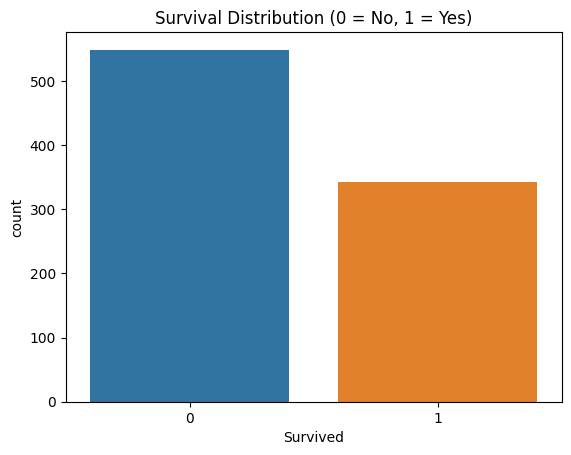

In [95]:
# Visualization (fixed warning)
sns.countplot(data=train_df, x='Survived', hue='Survived', legend=False)
plt.title('Survival Distribution (0 = No, 1 = Yes)')
plt.show()

# Insight:
# - Around 62% passengers died, 38% survived
# - Dataset is moderately imbalanced

In [96]:
# Survival by gender
gender_survival = train_df.groupby('Sex')['Survived'].mean()
print(gender_survival)

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


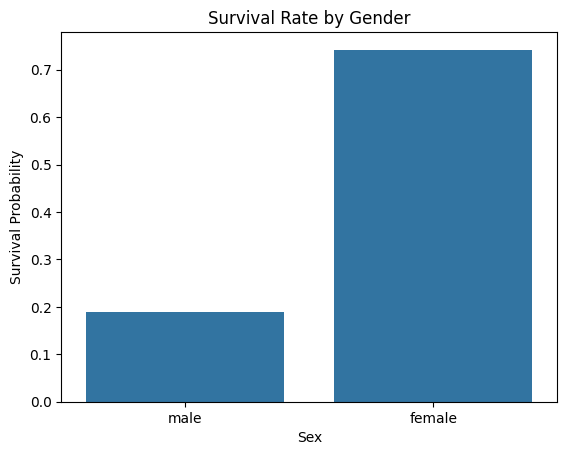

In [97]:
# Visualization
sns.barplot(data=train_df, x='Sex', y='Survived', errorbar=None)
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Probability')
plt.show()

# Insight:
# - Females (~74%) had significantly higher survival than males (~19%)
# - Indicates strong rescue priority based on gender
# - Sex is a highly important feature for prediction

In [98]:
# Survival by class
class_survival = train_df.groupby('Pclass')['Survived'].mean()
print(class_survival)

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


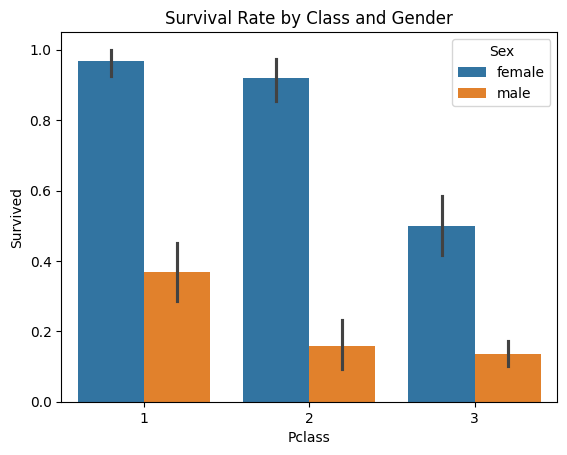

In [99]:
# Visualization
sns.barplot(data=train_df, x='Pclass', y='Survived', hue='Sex')
plt.title('Survival Rate by Class and Gender')
plt.show()

# Insight:
# - Survival decreases from 1st class (~63%) to 3rd class (~24%)
# - Indicates strong impact of socio-economic status
# - Higher class passengers had better access to safety

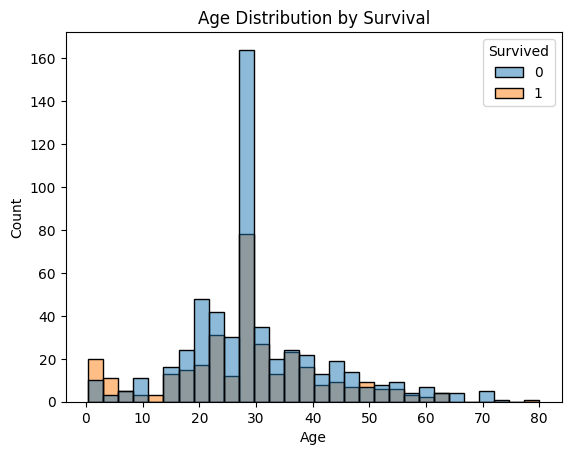

In [100]:
# Age distribution by survival
sns.histplot(data=train_df, x='Age', hue='Survived', bins=30)
plt.title('Age Distribution by Survival')
plt.show()

# Insight:
# - Younger passengers show slightly higher survival trends
# - Age has moderate influence compared to Sex and Pclass

In [101]:
# Final Conclusion:

# - Gender is the strongest predictor of survival
# - Passenger class significantly impacts survival chances
# - Age has moderate influence
# - Dataset is moderately imbalanced
# - These features will be important for ML modeling